In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os
from mpl_toolkits.mplot3d import Axes3D
from lib.strings import title2
from rich import print

plt.rcParams['figure.figsize'] = [16, 8]
plt.rcParams.update({'font.size':18})

<====================================================================================================>
                                 Principal Component Analisys Test                                  
<====================================================================================================>


<ipython-input-5-682bb6c7da24>:17: MatplotlibDeprecationWarning: Case-insensitive properties were deprecated in 3.3 and support will be removed two minor releases later
  ax1.plot(X[0,:],X[1,:], '.', Color='k')
<ipython-input-5-682bb6c7da24>:40: MatplotlibDeprecationWarning: Case-insensitive properties were deprecated in 3.3 and support will be removed two minor releases later
  ax2.plot(Xavg[0] + Xstd[0,:], Xavg[1] + Xstd[1,:],'-', color='r', LineWidth=3)
<ipython-input-5-682bb6c7da24>:41: MatplotlibDeprecationWarning: Case-insensitive properties were deprecated in 3.3 and support will be removed two minor releases later
  ax2.plot(Xavg[0] + 2*Xstd[0,:], Xavg[1] + 2*Xstd[1,:],'-', color='r', LineWidth=3)
<ipython-input-5-682bb6c7da24>:42: MatplotlibDeprecationWarning: Case-insensitive properties were deprecated in 3.3 and support will be removed two minor releases later
  ax2.plot(Xavg[0] + 3*Xstd[0,:], Xavg[1] + 3*Xstd[1,:],'-', color='r', LineWidth=3)
<ipython-input-5-682bb6c7da24>:

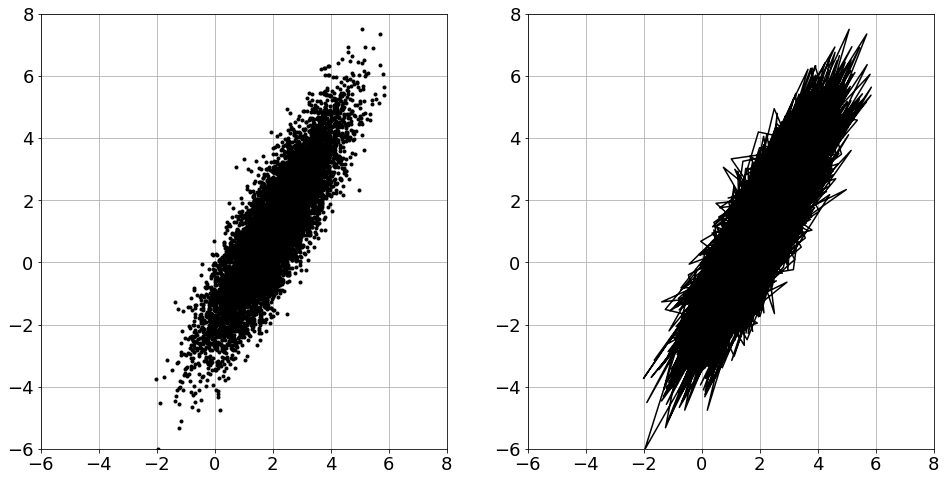

In [5]:
title2('Principal Component Analisys Test', 100)

xC = np.array([2, 1])      # Centro dos dados (média)
sig = np.array([2, 0.5])   # Eixos principais

theta = np.pi/3            # Rotacionar a "núvem" de variância por pi/3

R = np.array([[np.cos(theta), -np.sin(theta)],    # Matriz de rotação
              [np.sin(theta), np.cos(theta)]])

nPoints = 10000            # Número de pontos no gráfico
X = R @ np.diag(sig) @ np.random.randn(2,nPoints) + np.diag(xC) @ np.ones((2,nPoints))

# Plotando PCA
fig = plt.figure()
ax1 = fig.add_subplot(121)
ax1.plot(X[0,:],X[1,:], '.', Color='k')
ax1.grid() 
plt.xlim((-6, 8))
plt.ylim((-6, 8))


Xavg = np.mean(X, axis=1)              # Linha média
B = X - np.tile(Xavg,(nPoints,1)).T    # Dados subtraídos pela média

U,S,VT = np.linalg.svd(B/np.square(nPoints), full_matrices=0)

# Plotando PCA com linhas auxiliares
ax2 = fig.add_subplot(122)
ax2.plot(X[0,:],X[1,:], '.', color='k')     # Plotar os dados para sobrepor o PCA
ax2.grid()
plt.xlim((-6, 8))
plt.ylim((-6, 8))

theta = 2*np.pi * np.arange(0,1,0.01)

# 1o "confidence interval", linhas vermelhas dos intervalos de desvio-padrão
Xstd = U @ np.diag(S) @ np.array([np.cos(theta),np.sin(theta)])    # T = US = BV

ax2.plot(Xavg[0] + Xstd[0,:], Xavg[1] + Xstd[1,:],'-', color='r', LineWidth=3)
ax2.plot(Xavg[0] + 2*Xstd[0,:], Xavg[1] + 2*Xstd[1,:],'-', color='r', LineWidth=3)
ax2.plot(Xavg[0] + 3*Xstd[0,:], Xavg[1] + 3*Xstd[1,:],'-', color='r', LineWidth=3)

# Plotando os componentes principais U[:,0]S[0] e
ax2.plot(np.array([Xavg[0], Xavg[0]+U[0,0]*S[0]]),
         np.array([Xavg[1], Xavg[1]+U[1,0]*S[0]]),'-', color='cyan', LineWidth=5)

# U[:,1]S[1] (linhas azuis)
ax2.plot(np.array([Xavg[0], Xavg[0]+U[0,1]*S[1]]),
         np.array([Xavg[1], Xavg[1]+U[1,1]*S[1]]),'-', color='cyan', LineWidth=5)


<====================================================================================================>
                                    Ovarian Cancer Data PCA Test                                    
<====================================================================================================>


<function matplotlib.pyplot.show(close=None, block=None)>

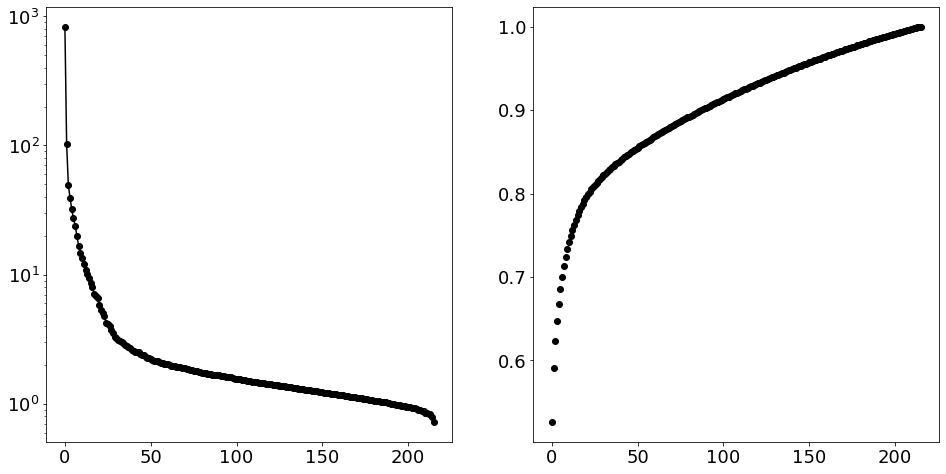

In [3]:
title2('Ovarian Cancer Data PCA Test', 100)

obs = np.loadtxt(os.path.join('DATA','ovariancancer_obs.csv'), delimiter=',')
f = open(os.path.join('DATA','ovariancancer_grp.csv'), 'r')
grp = f.read().split('\n')

U, S, VT = np.linalg.svd(obs,full_matrices=0)

fig1 = plt.figure()
ax1 = fig1.add_subplot(121)
ax1.semilogy(S,'-o',color='k')
ax2 = fig1.add_subplot(122)
ax2.plot(np.cumsum(S)/np.sum(S),'o',color='k')

plt.show

(216, 4000)

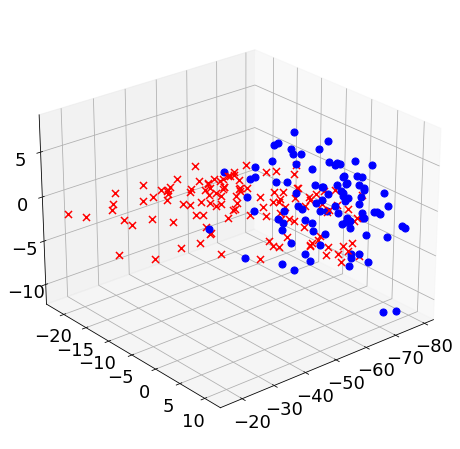

In [4]:
# Plot em 3D

fig2 = plt.figure()
ax = fig2.add_subplot(111,projection='3d')
print(obs.shape)
for j in range(obs.shape[0]):
    x = VT[0,:] @ obs[j,:].T
    y = VT[1,:] @ obs[j,:].T
    z = VT[2,:] @ obs[j,:].T
    
    if grp[j] == "Cancer":
        ax.scatter(x,y,z,marker='x',color='r',s=50) # Com câncer
    else:
        ax.scatter(x,y,z,marker='o',color='b',s=50) # Sem câncer

ax.view_init(25,50)
plt.show()